<a href="https://colab.research.google.com/github/opherdonchin/BayesShortCourse/blob/main/sleep/solved/09_exgaussian_distributional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sleep deprivation 9 — Ex-Gaussian distributional model

Represent right skew directly with an ex-Gaussian likelihood: a Gaussian component plus an exponential tail, rather than a log transform.

## Setup

This course pins PyMC and the modular ArviZ packages for reproducibility because their APIs can change across major versions.

In [1]:
%pip install -q \
    "pandas==2.2.3" \
    "pymc==6.3.2" \
    "arviz-base==1.3.0" \
    "arviz-stats==1.3.2" \
    "arviz-plots[matplotlib]==1.3.1"

Note: you may need to restart the kernel to use updated packages.


D:\Repositories\BayesShortCourse\tmp\colabenv\Scripts\python.exe: No module named pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import xarray as xr
import pymc as pm
import arviz_base as azb
import arviz_plots as azp
import arviz_stats as azs

RANDOM_SEED = 20260924
azp.style.use("arviz-variat")

print("PyMC:", pm.__version__)
print("arviz-base:", azb.__version__)
print("arviz-plots:", azp.__version__)
print("arviz-stats:", azs.__version__)

g++ not available, if using conda: `conda install gxx`


PyMC: 6.3.2
arviz-base: 1.3.0
arviz-plots: 1.3.1
arviz-stats: 1.3.2


## Data

The original study contains two adaptation/training days followed by a baseline measurement and then seven nights of severe sleep restriction. You can read about the original study here: [Belenky J Sleep Res. 2003](https://doi.org/10.1046/j.1365-2869.2003.00337.x)

Following the chapter, we drop original days 0–1 and subtract 2 from the remaining day number. Therefore **`Days = 0` is the baseline measurement before sleep deprivation begins**.

That zero point is scientifically meaningful, so every model in this sequence keeps `Days` on its natural scale (no centering). The intercept prior is therefore a prior on baseline reaction time rather than reaction time at the average deprivation day.

In [3]:
DATA_URL = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/lme4/sleepstudy.csv"

sleep = pd.read_csv(DATA_URL).drop(columns="rownames")
sleep = sleep.loc[sleep["Days"] >= 2].copy()
sleep["Days"] = sleep["Days"] - 2
sleep["Subject"] = sleep["Subject"].astype(str)
sleep = sleep.reset_index(drop=True)

print(f"{sleep['Subject'].nunique()} participants, {len(sleep)} observations")
print(f"Days: {sleep['Days'].min()} to {sleep['Days'].max()}")
sleep.head()

18 participants, 144 observations
Days: 0 to 7


,Reaction,Days,Subject
0,250.8006,0,308
1,321.4398,1,308
2,356.8519,2,308
3,414.6901,3,308
4,382.2038,4,308


In [4]:
# Plotting helpers (presentation only). Every plot uses the golf-notebook grammar:
# orange mean line, blue 50% and 90% HDI bands, black observed points.
DRAW_COLOR = "#12505e"  # darker shade of the band colour C0
LM_VISUALS = {
    "pe_line": {"color": "C1"},
    "ci_band": {"color": "C0"},
    "observed_scatter": {"color": "black", "alpha": 1, "zorder": 3, "s": 10},
}
PARTICIPANT_DAY = xr.Coordinates.from_pandas_multiindex(
    pd.MultiIndex.from_frame(sleep[["Subject", "Days"]], names=["participant", "day"]),
    "obs_id",
)

def add_interval_legend(target, line_label="mean", draws_label=None):
    """Compact one-row legend above an axis or above a whole panel grid."""
    handles = [
        Line2D([0], [0], color="C1", lw=1.6, label=line_label),
        Patch(facecolor="C0", alpha=0.9, label="50% HDI"),
        Patch(facecolor="C0", alpha=0.28, label="90% HDI"),
    ]
    if draws_label:
        handles.append(Line2D([0], [0], color=DRAW_COLOR, lw=0.9, label=draws_label))
    handles.append(Line2D([0], [0], marker="o", linestyle="none", color="black",
                          markersize=4.5, label="observed"))
    style = dict(ncols=len(handles), fontsize=8, handlelength=1.4, handletextpad=0.45,
                 columnspacing=0.9, frameon=False)
    if isinstance(target, plt.Figure):
        target.legend(handles=handles, loc="outside upper left", **style)
    else:
        target.legend(handles=handles, loc="lower left", bbox_to_anchor=(0, 1.01),
                      borderaxespad=0, **style)

def plot_population(dt, var, group="posterior"):
    """Single-panel trend of `var` against days, with all 144 raw observations."""
    pc = azp.plot_lm(
        dt, x="days", y=var, y_obs="Reaction", group=group, plot_dim="obs_id",
        ci_prob=(0.50, 0.90), ci_kind="hdi", point_estimate="mean", smooth=False,
        figure_kwargs={"figsize": (7, 4)}, visuals=LM_VISUALS,
    )
    ax = plt.gca()
    ax.set(xlabel="Days of sleep deprivation", ylabel="Reaction time (ms)")
    add_interval_legend(ax)
    return pc

def plot_participants(dt, group, var):
    """One panel per participant: bands for `var` against days, with that participant's data."""
    def reshape(ds):
        return ds.assign_coords(PARTICIPANT_DAY).unstack("obs_id")
    panels = xr.DataTree.from_dict({
        group: reshape(dt[group].to_dataset()),
        "observed_data": reshape(dt["observed_data"].to_dataset()),
        "constant_data": reshape(dt["constant_data"].to_dataset()),
    })
    pc = azp.plot_lm(
        panels, x="days", y=var, y_obs="Reaction", group=group, plot_dim="day",
        ci_prob=(0.50, 0.90), ci_kind="hdi", point_estimate="mean", smooth=False,
        cols=["participant"], col_wrap=6,
        figure_kwargs={"figsize": (11, 5.5), "sharex": True, "sharey": True},
        visuals={**LM_VISUALS, "xlabel": False, "ylabel": False},
    )
    fig = pc.viz["figure"].item()
    fig.supxlabel("Days of sleep deprivation")
    fig.supylabel("Reaction time (ms)")
    add_interval_legend(fig)
    return pc

In [5]:
participants = sorted(sleep["Subject"].unique(), key=int)
participant_idx = sleep["Subject"].map({p: i for i, p in enumerate(participants)}).to_numpy()

## 9.1 Modeling a right tail directly

Can an ex-Gaussian likelihood represent right-skewed reaction times while keeping the main location effect on the millisecond scale?

PyMC's ex-Gaussian uses `mu`, `sigma`, and `nu`; its expected reaction time is $\mu+\nu$. We model participant variation in `mu` and `sigma`; `nu` gets a population-only log-scale prior. Stated in milliseconds: the Gaussian component's residual SD is centred around 30 ms (90% prior range about 13–68 ms), the exponential tail has a mean around 50 ms (90% range about 15–170 ms), and participants' residual SDs typically differ by a factor of about 1.4.

In [6]:
coords = {"obs_id": np.arange(len(sleep)), "participant": participants}

with pm.Model(coords=coords) as model:
    days = pm.Data("days", sleep["Days"].to_numpy(), dims="obs_id")
    pidx = pm.Data("participant_idx", participant_idx, dims="obs_id")

    intercept = pm.Normal("intercept", mu=250, sigma=100)
    slope = pm.Normal("slope", mu=0, sigma=20)

    participant_intercept_sd = pm.Exponential("participant_intercept_sd", lam=0.04)
    participant_intercept_z = pm.Normal("participant_intercept_z", 0, 1, dims="participant")
    participant_intercept = pm.Deterministic(
        "participant_intercept",
        participant_intercept_sd * participant_intercept_z,
        dims="participant",
    )

    participant_slope_sd = pm.Exponential("participant_slope_sd", lam=0.10)
    participant_slope_z = pm.Normal("participant_slope_z", 0, 1, dims="participant")
    participant_slope = pm.Deterministic(
        "participant_slope",
        participant_slope_sd * participant_slope_z,
        dims="participant",
    )

    # Gaussian-component residual scale: log-linear, own participant term
    sigma_intercept = pm.Normal("sigma_intercept", mu=np.log(30), sigma=0.5)
    participant_sigma_sd = pm.Exponential("participant_sigma_sd", lam=3)
    participant_sigma_z = pm.Normal("participant_sigma_z", 0, 1, dims="participant")
    participant_sigma = pm.Deterministic(
        "participant_sigma",
        participant_sigma_sd * participant_sigma_z,
        dims="participant",
    )
    residual_scale = pm.Deterministic(
        "residual_scale",
        pm.math.exp(sigma_intercept + participant_sigma),
        dims="participant",
    )

    # exponential-tail mean: log-linear, population-only
    nu_intercept = pm.Normal("nu_intercept", mu=np.log(50), sigma=0.75)
    tail = pm.Deterministic("tail", pm.math.exp(nu_intercept))

    population_mu = pm.Deterministic(
        "population_mu", intercept + slope * days, dims="obs_id"
    )
    mu = pm.Deterministic(
        "mu",
        population_mu
        + participant_intercept[pidx]
        + participant_slope[pidx] * days,
        dims="obs_id",
    )
    sigma = pm.Deterministic("sigma", residual_scale[pidx], dims="obs_id")

    # For an ex-Gaussian, the mean reaction time is mu + nu (not mu alone).
    mean_rt = pm.Deterministic("mean_rt", mu + tail, dims="obs_id")
    population_mean_rt = pm.Deterministic(
        "population_mean_rt", population_mu + tail, dims="obs_id"
    )

    pm.ExGaussian(
        "Reaction",
        mu=mu,
        sigma=sigma,
        nu=tail,
        observed=sleep["Reaction"].to_numpy(),
        dims="obs_id",
    )

Before fitting, ask what reaction times the priors make plausible. Each panel is one participant. The bands are the prior predictive distribution of a single new reaction-time measurement on each day. The black points are that participant's data, shown only as a reference: they do not condition the prior.

Sampling: [Reaction, intercept, nu_intercept, participant_intercept_sd, participant_intercept_z, participant_sigma_sd, participant_sigma_z, participant_slope_sd, participant_slope_z, sigma_intercept, slope]


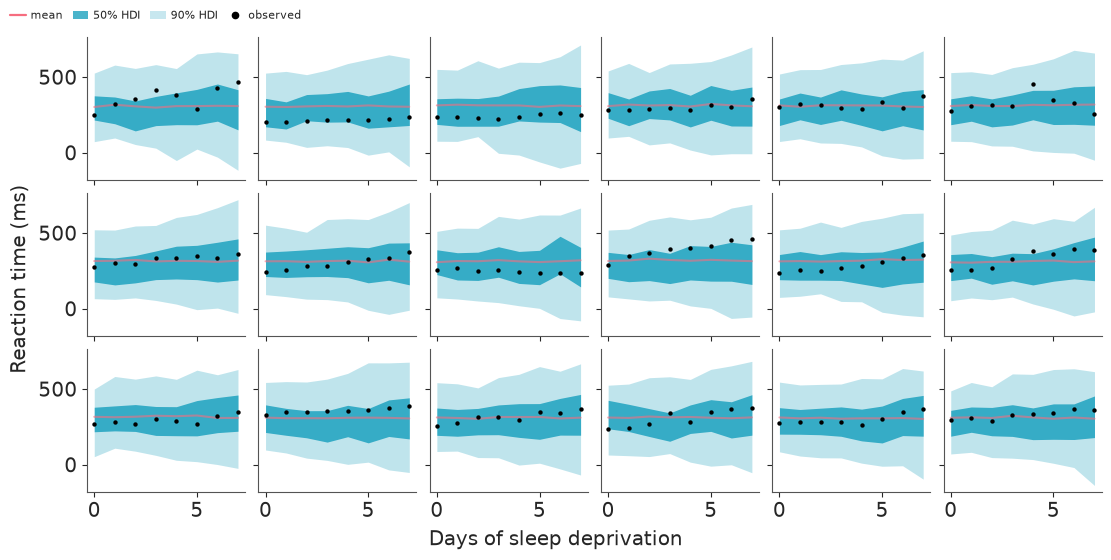

In [7]:
with model:
    prior = pm.sample_prior_predictive(
        draws=500, var_names=["Reaction"], random_seed=RANDOM_SEED
    )

plot_participants(prior, "prior_predictive", "Reaction")
plt.show()

## 9.2 Ex-Gaussian components

What do the fitted ex-Gaussian location, spread, and tail parameters imply about participant trajectories?

Do not interpret the fit until the sampler diagnostics are acceptable: no divergences, R-hat ≤ 1.01, and bulk and tail ESS in the hundreds or more.

In [8]:
with model:
    idata = pm.sample(
        draws=1000, tune=2000, chains=4, target_accept=0.95, random_seed=RANDOM_SEED
    )

print("Divergences:", int(idata["sample_stats"]["diverging"].sum().item()))
azs.summary(idata, var_names=["intercept", "slope", "participant_intercept_sd", "participant_slope_sd", "sigma_intercept", "participant_sigma_sd", "nu_intercept"], ci_prob=0.90, ci_kind="hdi", round_to=2)

Initializing NUTS using jitter+adapt_diag...


D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\pytensor\tensor\rewriting\elemwise.py:1004: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [intercept, slope, participant_intercept_sd, participant_intercept_z, participant_slope_sd, participant_slope_z, sigma_intercept, participant_sigma_sd, participant_sigma_z, nu_intercept]


D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 45 seconds.


There were 6 divergences after tuning. Increase `target_accept` or reparameterize.


Divergences: 6


,mean,sd,hdi90_lb,hdi90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept,260.48,8.94,246.61,275.70,1291.89,1670.56,1.0,0.25,0.17
slope,11.36,2.01,8.14,14.62,1103.58,1400.98,1.0,0.06,0.04
participant_intercept_sd,33.90,6.53,23.94,43.84,1652.79,2221.19,1.0,0.16,0.15
participant_slope_sd,7.46,1.58,4.87,9.77,1632.76,2152.88,1.0,0.04,0.03
sigma_intercept,2.79,0.20,2.45,3.09,1979.36,2394.03,1.0,0.00,0.00
participant_sigma_sd,0.76,0.19,0.45,1.03,1697.47,2243.34,1.0,0.00,0.00
nu_intercept,1.96,0.32,1.47,2.49,4315.09,3054.25,1.0,0.00,0.01


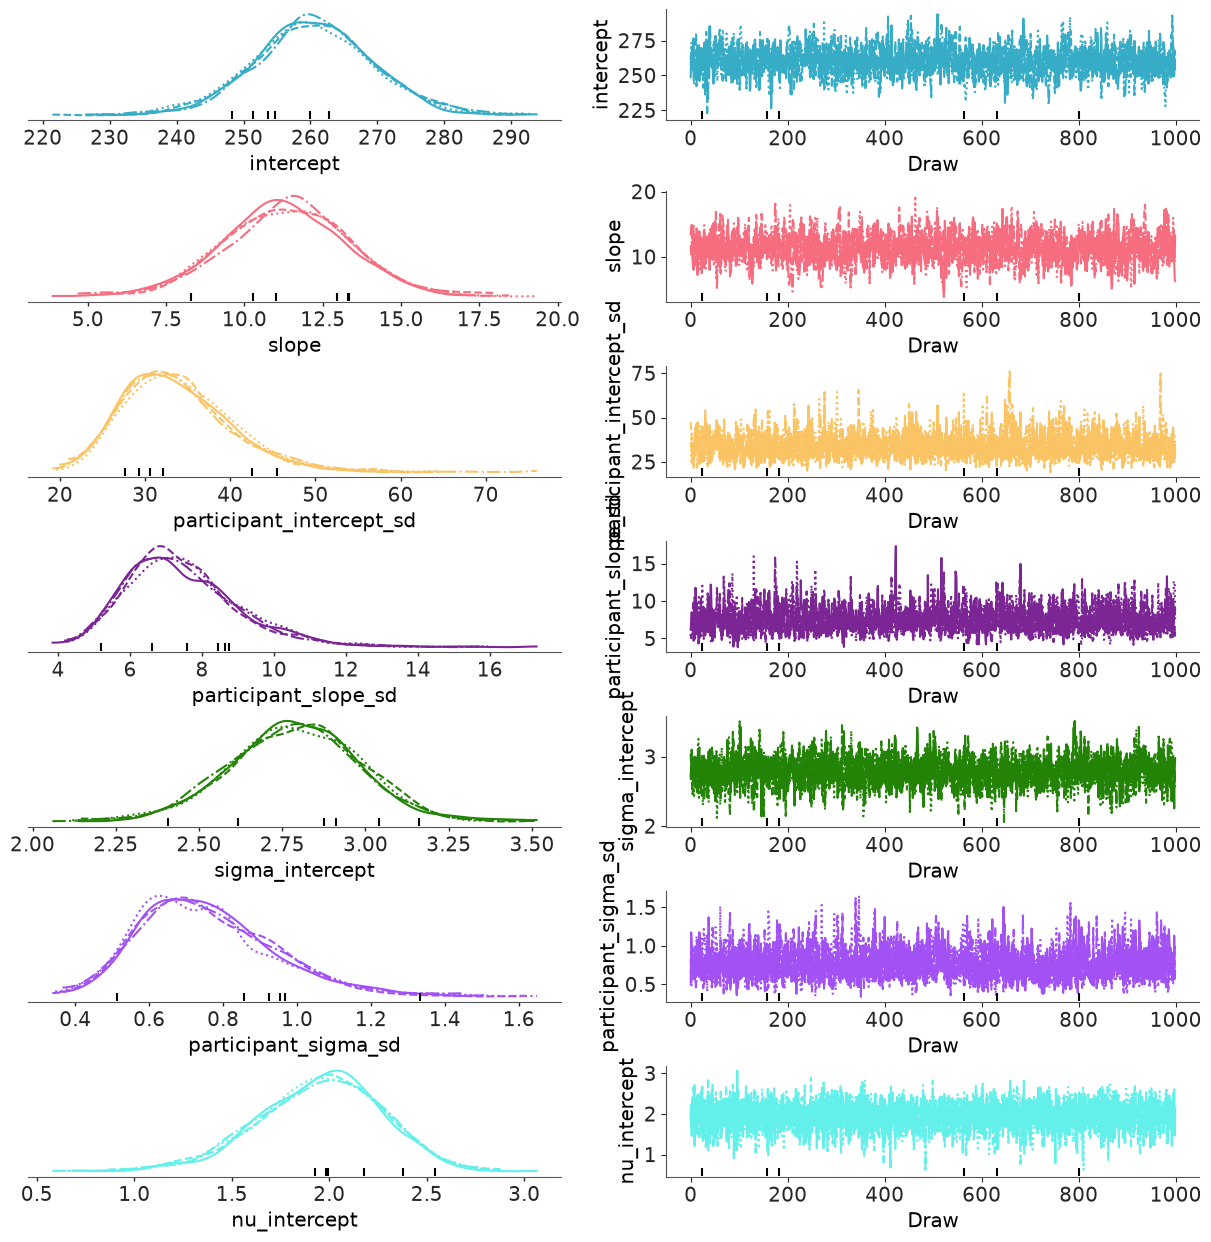

In [9]:
azp.plot_trace_dist(idata, var_names=["intercept", "slope", "participant_intercept_sd", "participant_slope_sd", "sigma_intercept", "participant_sigma_sd", "nu_intercept"]);

This plot shows posterior uncertainty in the expected reaction time (on the millisecond scale) of a *typical* participant. It does not include between-participant or measurement-to-measurement variation.

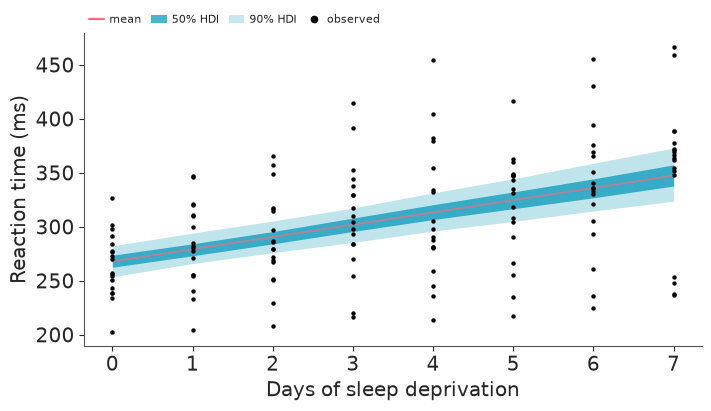

In [10]:
plot_population(idata, "population_mean_rt")
plt.show()

Each panel shows posterior uncertainty in that participant's expected reaction time. These are mean trajectories, not new measurements.

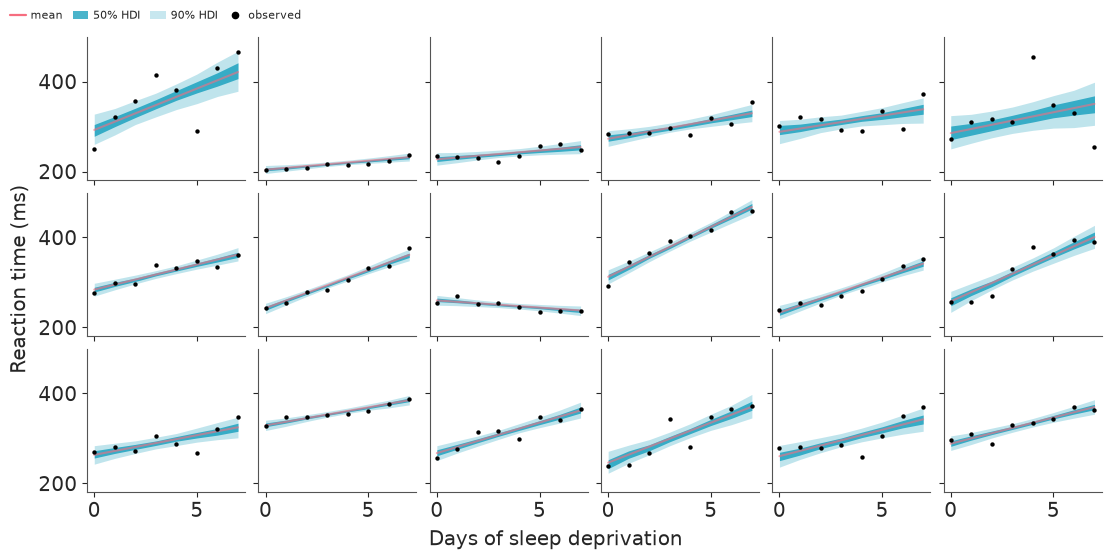

In [11]:
plot_participants(idata, "posterior", "mean_rt")
plt.show()

## 9.3 Predictive behavior of the informed model

Does the informed-prior ex-Gaussian reproduce the observed reaction-time distribution?

Now generate new reaction times from the fitted model. The layout is the same as in the prior predictive check; the difference is that these predictions are conditioned on the data. The bands are the distribution of a single new measurement for each participant and day.

Sampling: [Reaction]


D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

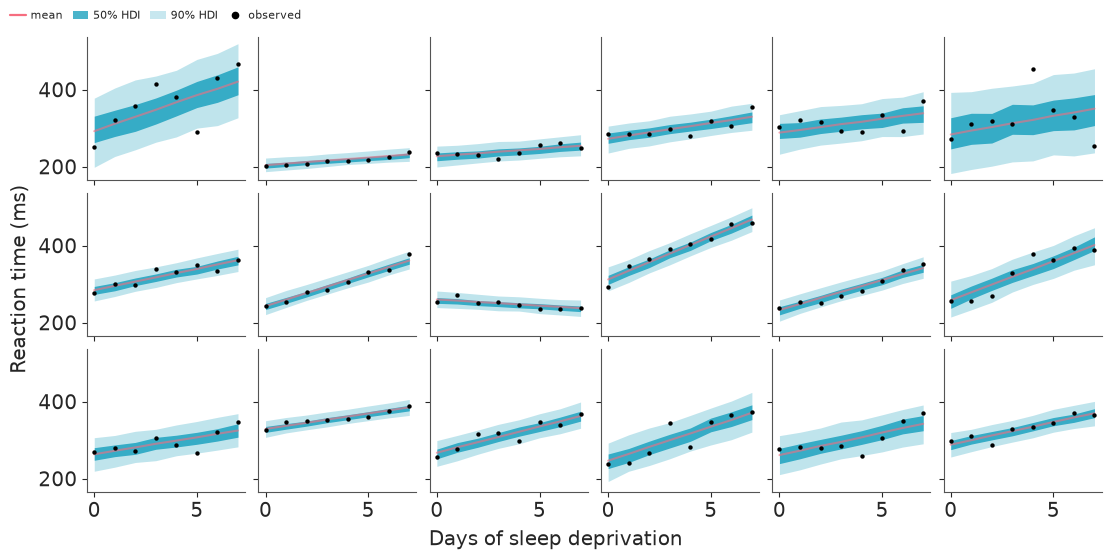

In [12]:
with model:
    pm.sample_posterior_predictive(
        idata, var_names=["Reaction"], extend_inferencedata=True, random_seed=RANDOM_SEED
    )

plot_participants(idata, "posterior_predictive", "Reaction")
plt.show()

The panel plot checks trajectories. This check pools all 144 measurements and asks whether simulated datasets reproduce the overall *shape* of the reaction-time distribution, especially its right tail.

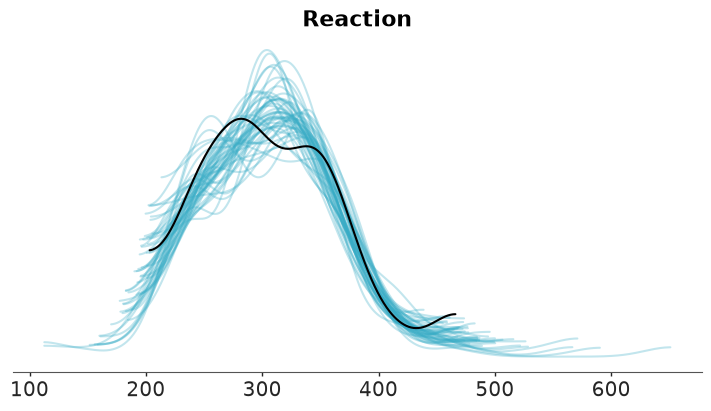

In [13]:
azp.plot_ppc_dist(idata, var_names=["Reaction"], kind="kde", figure_kwargs={"figsize": (7, 4)});

## 9.4 Where priors may matter

Which parts of this flexible ex-Gaussian model should be most vulnerable if prior information is weakened?

The ex-Gaussian is more flexible, which makes prior information more consequential. The next two notebooks repeat the same model with naive priors that ignore the log link and with deliberately flat common-effect priors, to expose that dependence.